# Tiny Shakespeare: Four Normalization Variants

**First stage: four runs to 1,500 completed optimizer updates each, one seed. Later resume each run up to 5,000 updates.**

This notebook uses MiniP with a smaller hidden width (256 instead of 384) and four attention heads. Depth is four, and the MLP expansion remains four. Other training settings are based on the original nanoGPT Tiny Shakespeare preset. The delivered notebook has no executed cells or training outputs.

The primary question is whether adding normalization immediately before the attention output projection $W_O$ and the MLP output projection $W_2$ improves loss beyond standard pre-normalization.

Compare **A with B**, and **C with D**. Comparisons between LayerNorm and RMSNorm are secondary. This first experiment fixes depth at four layers. CompleteP and depth sweeps are reserved for a separate experiment.

| ID | Variant | Existing pre-norms and final norm | Extra norm before both $W_O$ and $W_2$ |
|---|---|---|---|
| A | LayerNorm | LayerNorm | No |
| B | LayerNorm + extra | LayerNorm | LayerNorm |
| C | RMSNorm | RMSNorm | No |
| D | RMSNorm + extra | RMSNorm | RMSNorm |

Both extra locations are enabled together. This experiment does not identify which individual location causes an effect.

**Current continuation:** resume the existing 1,500-update checkpoints to **5,000 total updates per run**. Save resumable checkpoints every 100 updates and at the target. Existing loss histories are retained.

## Model architecture and normalization locations

Token embeddings + learned absolute position embeddings → embedding dropout → four sequential pre-norm Transformer layers → final norm → tied vocabulary projection → next-character cross-entropy loss.

Within each layer:

1. Pre-norm → $W_Q,W_K,W_V$ → causal attention → concatenate heads → **optional extra norm** → $W_O$ → dropout → residual addition.
2. Pre-norm → $W_1$ → **GELU** → **optional extra norm** → $W_2$ → dropout → residual addition.

The extra attention norm operates over the concatenated **256-dimensional** vector. The extra MLP norm operates over the **1,024-dimensional** GELU output. Both normalize the final feature dimension separately at each token position. They are before the output matrices, not after the residual addition.

| Setting | Value |
|---|---|
| Transformer layers | 4 |
| Hidden width | 256 |
| Attention heads / width per head | 4 / 64 |
| Attention score multiplier | $1/\sqrt{64}=1/8$ |
| MLP width / expansion | 1,024 / 4× |
| Context length | 256 characters |
| Vocabulary | 65 characters, verified against local metadata |
| Dropout | 0.2 during training; disabled during evaluation |
| Linear and normalization biases | Disabled |
| Normalization scale $\gamma$ | Learnable; initialized to 1 |
| Norm epsilon | $10^{-5}$ for both LayerNorm and RMSNorm |
| Token embedding / output head | Shared weights |
| Attention and MLP residual multipliers | 1.0; no CompleteP depth scaling |
| Total parameters, A and C | 3,230,208, including position embeddings; tied weights counted once |
| Total parameters, B and D | 3,235,328; extra norms add 5,120 scale parameters |

LayerNorm subtracts the feature mean and normalizes by feature variance. RMSNorm normalizes by the root mean square without subtracting the mean. Both use the same explicit epsilon and a learnable scale.

## Initialization and optimizer

| Item | Setting |
|---|---|
| Token/position embeddings, QKV and $W_1$ | Independent normal entries, mean 0, standard deviation 0.02 |
| $W_O$ and $W_2$ | Normal entries, mean 0, standard deviation $0.02/\sqrt{2\times4}\approx0.007071$ |
| All norm scales, including extra norms | 1.0 |
| Bias initialization | Not applicable: biases are disabled |
| Optimizer | AdamW |
| Betas | $(0.9,0.99)$, matching the Shakespeare preset |
| Adam epsilon | $10^{-8}$; distinct from norm epsilon |
| Weight decay | 0.1 on matrices/embeddings; 0 on norm scales |
| Gradient clipping | Global gradient norm capped at 1.0 before each update |
| Peak learning rate | 0.001 |
| Warmup | First 100 updates; current MiniP `get_lr` implementation |
| Cosine decay horizon | 5,000 updates, retained from the original preset |
| Minimum scheduled learning rate | 0.0001 at the end of the 5,000-update schedule |

**The run stops after 1,500 updates; the learning-rate schedule is not compressed to 1,500.** This preserves the schedule used by the earlier 200-update probe. It is a truncated original training schedule, not a complete decay to the minimum learning rate. The last update uses schedule index 1499. Warmup at zero-based index $k<100$ uses $0.001(k+1)/101$; the subsequent cosine follows `train.py:get_lr`.

The ordinary nanoGPT output-projection initialization depends on depth, but there is no explicit depth multiplier in residual addition. CompleteP initialization and optimizer adjustments are not enabled.

On continuation, keep the 5,000-update decay horizon and 100-update warmup unchanged. The next update after a 1,500-update checkpoint uses schedule index 1500: warmup is not restarted.

## Does CompleteP use warmup?

**Yes in the paper's formal training experiments.** Section 3 specifies linear warmup for the shorter of 10% of training steps or the steps corresponding to 375 million tokens, followed by linear learning-rate decay to zero. See [CompleteP v4, Section 3](https://arxiv.org/html/2505.01618v4#S3).

**The repository's short Figure 7 coordinate checks do not.** The [CompleteP coordinate-check launcher](../../CompleteP/completep_examples/coord_check_shakespeare_char/depth_alpha_1_aka_completep/run.sh) sets `max_iters=10` and `decay_lr=False`. In [the author's trainer](../../CompleteP/train.py), that flag bypasses the warmup/decay function and uses the constant base learning rate.

Warmup is a training-schedule choice, not the definition of CompleteP parameterization. This notebook retains nanoGPT's 100-update warmup and cosine schedule; it does not adopt the paper's linear decay or CompleteP parameterization. The 1,500-update stopping point can be extended without restarting the schedule.

## Data, budget, evaluation, and interpretation

| Setting | Value |
|---|---|
| Dataset | Existing `data/shakespeare_char/train.bin`, `val.bin`, and `meta.pkl` |
| Split | Use the existing prepared train/validation split; do not repartition |
| Sampling | Random contiguous windows with replacement within each split |
| Batch size | 64 sequences |
| Gradient accumulation | 1 |
| Tokens per optimizer update | $64\times256=16,384$ |
| Updates / sampled training tokens per variant | 1,500 / 24,576,000, including repeated tokens |
| Initialization seed | 1337 |
| Training-window / evaluation-window seeds | 81001 / 81002 |
| Evaluation | Before training and after every 50 completed updates, including update 1,500 |
| Evaluation batches | 20 per split per evaluation; 325,120 token positions per split, with possible overlap |
| Device and precision | Apple MPS, float32, without compilation or mixed precision |

Training and evaluation use independent CPU random generators. All four variants receive the same ordered training windows and the same fixed evaluation windows. A fixed 5,000-update window plan is generated from the start, regardless of the current stopping target. Continuation indexes into this same plan. Common initial matrices are verified by a fingerprint. Extra norm scales are initialized to constants. Initial losses can still differ because normalization changes the function.

Evaluation reports mean next-character cross-entropy in **nats per token** with dropout disabled, including on the training split. Per-update training-batch losses are also saved; these use dropout and changing batches, so they are noisier and differ from evaluation losses.

The small probe evaluates more frequently and uses fewer batches than the original preset (every 250 steps, 200 batches per split). Width and attention-head count are intentionally reduced; other model and optimizer settings follow that preset. Evaluation windows do not consume training-window RNG state.

Primary outputs: train/validation loss curves against completed updates, final validation loss, and paired validation-loss differences. A positive `baseline loss − extra-norm loss` means the extra norm helps. Also plot validation loss against accumulated active wall time across sessions, which includes evaluation and most saving overhead, but excludes model construction, checkpoint loading, and time between sessions. The final checkpoint write of a session is not included in its saved elapsed time.

This is one seed and an early training budget. A declining loss does not establish convergence. Any differences are descriptive and need longer runs and multiple seeds for stronger conclusions. Timing may vary with other applications and sustained device load.

## Running, saving, and resuming

Select `Code/MiniP/.venv` as the Python environment, restart the kernel, and run cells in order. Required packages: PyTorch with `F.rms_norm` and MPS RNG-state APIs, NumPy, and Matplotlib. Set `PROJECT_ROOT` in the imports cell if repository discovery fails.

**First stage:** leave `RESUME_RUN_DIR = None` and `max_updates = 1500`. The execution cell creates a fresh directory and runs A, B, C, and D sequentially to 1,500 completed updates each.

**Continue to 5,000:** set `max_updates = 5000` and set `RESUME_RUN_DIR` to the exact directory printed by the first stage. Restart the kernel and run all cells. This adds 3,500 updates per variant, not 5,000 additional updates. Each variant loads its own latest checkpoint. Already-completed variants are skipped if they have reached the requested target.

Only change `max_updates` and, optionally, `checkpoint_interval` when resuming. Keep architecture, optimizer, learning-rate schedule, seeds, data, evaluation protocol, and device fixed. The notebook checks compatibility and rejects mismatched runs instead of silently mixing them. Old metrics-only runs from the earlier notebook cannot be resumed because they have no model/optimizer checkpoints.

Checkpoints are saved at update 0, every 100 completed updates, and at the requested stopping target. Each includes model weights, AdamW moments/step counters, completed updates, loss history, and Python/NumPy/PyTorch CPU/MPS random states. Restoring MPS RNG state also restores the dropout random stream. The next learning rate is computed from the restored global update count.

Metrics are saved every 50 updates. After an interruption, continuation starts from the latest fully written checkpoint; up to about 100 later updates may need to be recomputed. Checkpoint histories are authoritative and replace any newer metrics-only entries on resume. Checkpoints use a temporary file and replacement so an incomplete write does not overwrite the last good checkpoint.

Outputs live under `results/shakespeare-normalization/<timestamp>-<id>/`: `metrics.json`, `A-last.pt` through `D-last.pt`, model/trainer/preset/notebook source snapshots, and PNG/PDF figures. Loading is intended only for these trusted local checkpoints. The notebook and result folders are currently ignored by Git and remain local unless explicitly added.

Source references: [model](../model.py), [trainer and schedule](../train.py), [Shakespeare preset](../config/train_shakespeare_char.py). Reproducibility checks reduce accidental protocol changes; bitwise replay across different hardware or library versions is not promised.

In [1]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# Standard-library utilities for paths, metadata, checkpointing, and timing.
from pathlib import Path
from datetime import datetime, timezone
from types import SimpleNamespace
from dataclasses import asdict
import copy
import random
import gc
import hashlib
import json
import math
import pickle
import shutil
import sys
import time
import uuid

# Numerical libraries and notebook display tools.
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# Locate MiniP without depending on the notebook server launch directory.
PROJECT_ROOT = None  # Optional: Path('/absolute/path/to/Code/MiniP')
if PROJECT_ROOT is None:
    candidates = []
    for parent in (Path.cwd(), *Path.cwd().parents):
        candidates.extend([parent, parent / 'Code' / 'MiniP'])
    PROJECT_ROOT = next((p for p in candidates
                         if (p / 'model.py').is_file()
                         and (p / 'config/train_shakespeare_char.py').is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Set PROJECT_ROOT to the MiniP repository and rerun this cell.')
PROJECT_ROOT = Path(PROJECT_ROOT).resolve()
sys.path.insert(0, str(PROJECT_ROOT))
# Import the actual repository implementation; do not duplicate the Transformer.
import model as model_module
import train as train_module
from model import GPT, GPTConfig
from train import get_lr
assert Path(model_module.__file__).resolve() == PROJECT_ROOT / 'model.py', 'Restart the kernel: another model module is already loaded.'
assert Path(train_module.__file__).resolve() == PROJECT_ROOT / 'train.py', 'Restart the kernel: another train module is already loaded.'
print('Repository:', PROJECT_ROOT)
print('PyTorch:', torch.__version__)
### End normalization-ablation code ###


Matplotlib is building the font cache; this may take a moment.


Repository: /Users/linyuntao/Library/Mobile Documents/iCloud~md~obsidian/Documents/obsidian/research_workspace/projects/Adam - Normalization/Code/MiniP
PyTorch: 2.14.0


## Editable experiment configuration

In [2]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# 1. Model architecture: four layers; four heads of width 64; MLP width 1,024.
SETTINGS = dict(
    n_layer=4,               # Number of sequential Transformer layers.
    n_embd=256,              # Hidden/residual-stream width.
    n_head=4,                # 256 / 4 = 64 features per attention head.
    mlp_ratio=4,             # The current model.py fixes the expansion to 4x.
    block_size=256,          # Context length in character tokens.
    vocab_size=65,           # Must match the prepared dataset metadata.
    dropout=0.2,             # Active during training; disabled for evaluation.
    bias=False,             # Disable linear biases and LayerNorm offsets.

    # 2. Initialization and normalization (ordinary nanoGPT parameterization).
    init_std=0.02,           # Embedding, QKV, and MLP expansion standard deviation.
    norm_eps=1e-5,           # Shared epsilon for LayerNorm and RMSNorm.
                            # Norm scales start at 1; output matrices use sigma/sqrt(2L).

    # 3. Data and training budget.
    batch_size=64,          # Number of context windows per update.
    gradient_accumulation_steps=1,
    max_updates=5000,       # TOTAL completed updates per variant; set 5000 to resume.

    # 4. AdamW update rule.
    beta1=0.9,              # First-moment moving-average coefficient.
    beta2=0.99,             # Second-moment coefficient from the Shakespeare preset.
    adam_eps=1e-8,          # Adam denominator epsilon, distinct from norm_eps.
    weight_decay=0.1,       # Matrices/embeddings only; norm scales have zero decay.
    grad_clip=1.0,          # Clip global gradient norm before optimizer.step().

    # 5. Learning-rate schedule: preserve this schedule when continuing a run.
    learning_rate=1e-3,     # Peak/base learning rate.
    warmup_iters=100,       # Warmup occurs only at global updates 1 through 100.
    lr_decay_iters=5000,    # Fixed cosine horizon and length of shared window plan.
    min_lr=1e-4,            # Minimum learning rate at the schedule horizon.

    # 6. Evaluation and durable checkpoints.
    eval_interval=50,       # Evaluate at step 0, every 50 updates, and the stop target.
    eval_batches=20,        # Fixed evaluation batches for EACH of train and val.
    checkpoint_interval=100,  # Save latest resumable state; also save at the target.

    # 7. Reproducibility: independent initialization, training, and evaluation seeds.
    seed=1337,              # Model initialization and initial dropout RNG seed.
    training_window_seed=81001,
    evaluation_window_seed=81002,

    # 8. Execution: full precision on the local Apple GPU.
    device='mps',
    dtype='float32',
)

# 9. Run selection. None creates a NEW experiment; a directory resumes all four.
RESUME_RUN_DIR = Path('/Users/linyuntao/Library/Mobile Documents/iCloud~md~obsidian/Documents/obsidian/research_workspace/projects/Adam - Normalization/Code/MiniP/results/shakespeare-normalization/20260914T195408Z-4a3ab271')
# Example for continuation (replace the path with the actual printed run directory):
# RESUME_RUN_DIR = Path('/absolute/path/to/results/shakespeare-normalization/<run-id>')
# Also set max_updates=5000 above; leave lr_decay_iters=5000 and warmup_iters=100.

# 10. The two paired ablations; do not change their identities when resuming.
VARIANTS = [
    dict(id='A', name='LayerNorm', norm_type='layernorm', extra_output_norm=False),
    dict(id='B', name='LayerNorm + extra', norm_type='layernorm', extra_output_norm=True),
    dict(id='C', name='RMSNorm', norm_type='rmsnorm', extra_output_norm=False),
    dict(id='D', name='RMSNorm + extra', norm_type='rmsnorm', extra_output_norm=True),
]

# Fail early if settings do not match the capabilities of this notebook/model.
cfg = SimpleNamespace(**SETTINGS)
assert cfg.device == 'mps' and torch.backends.mps.is_available(), 'MPS is required; no silent CPU fallback.'
assert cfg.dtype == 'float32' and cfg.gradient_accumulation_steps == 1
assert cfg.mlp_ratio == 4, 'Changing MLP expansion requires editing model.py.'
assert cfg.n_embd % cfg.n_head == 0
assert 0 < cfg.warmup_iters < cfg.lr_decay_iters
assert 0 < cfg.max_updates <= cfg.lr_decay_iters
assert cfg.eval_interval > 0 and cfg.eval_batches > 0 and cfg.checkpoint_interval > 0
assert cfg.checkpoint_interval % cfg.eval_interval == 0, 'Checkpoint intervals must align with evaluations.'
assert hasattr(torch.nn.functional, 'rms_norm')
assert hasattr(torch.mps, 'get_rng_state') and hasattr(torch.mps, 'set_rng_state')
print(json.dumps(SETTINGS, indent=2))
print('Tokens per update:', cfg.batch_size * cfg.block_size)
print('Total training tokens at this target:', cfg.max_updates * cfg.batch_size * cfg.block_size)
print('LR at the requested final update:', get_lr(cfg.max_updates - 1, cfg))
### End normalization-ablation code ###


{
  "n_layer": 4,
  "n_embd": 256,
  "n_head": 4,
  "mlp_ratio": 4,
  "block_size": 256,
  "vocab_size": 65,
  "dropout": 0.2,
  "bias": false,
  "init_std": 0.02,
  "norm_eps": 1e-05,
  "batch_size": 64,
  "gradient_accumulation_steps": 1,
  "max_updates": 5000,
  "beta1": 0.9,
  "beta2": 0.99,
  "adam_eps": 1e-08,
  "weight_decay": 0.1,
  "grad_clip": 1.0,
  "learning_rate": 0.001,
  "warmup_iters": 100,
  "lr_decay_iters": 5000,
  "min_lr": 0.0001,
  "eval_interval": 50,
  "eval_batches": 20,
  "checkpoint_interval": 100,
  "seed": 1337,
  "training_window_seed": 81001,
  "evaluation_window_seed": 81002,
  "device": "mps",
  "dtype": "float32"
}
Tokens per update: 16384
Total training tokens at this target: 81920000
LR at the requested final update: 0.00010000009248900101


## Prepare shared data windows (no training)

In [3]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# Read the already-prepared character-level split; never repartition on resume.
data_dir = PROJECT_ROOT / 'data' / 'shakespeare_char'
for filename in ('train.bin', 'val.bin', 'meta.pkl'):
    if not (data_dir / filename).is_file():
        raise FileNotFoundError(f'Missing prepared dataset file: {data_dir / filename}')
with (data_dir / 'meta.pkl').open('rb') as handle:
    metadata = pickle.load(handle)  # Trusted local dataset metadata.
assert metadata['vocab_size'] == cfg.vocab_size
data = {split: np.memmap(data_dir / f'{split}.bin', dtype=np.uint16, mode='r')
        for split in ('train', 'val')}
for split, values in data.items():
    assert len(values) > cfg.block_size and int(values.max()) < cfg.vocab_size
    print(split, 'characters:', len(values))

# Generate the FULL 5,000-update plan now. A 1,500-update run uses its prefix;
# continuation uses rows 1500 onward. Independent generators do not alter dropout RNG.
training_rng = torch.Generator().manual_seed(cfg.training_window_seed)
evaluation_rng = torch.Generator().manual_seed(cfg.evaluation_window_seed)
training_windows = torch.randint(len(data['train']) - cfg.block_size,
                                (cfg.lr_decay_iters, cfg.batch_size), generator=training_rng)
evaluation_windows = {
    split: torch.randint(len(values) - cfg.block_size,
                         (cfg.eval_batches, cfg.batch_size), generator=evaluation_rng)
    for split, values in data.items()
}

def make_batch(split, indices):
    """Construct next-character input/target pairs from specified window starts."""
    values = data[split]
    t = cfg.block_size
    x = torch.stack([torch.from_numpy(values[i:i+t].astype(np.int64)) for i in indices])
    y = torch.stack([torch.from_numpy(values[i+1:i+t+1].astype(np.int64)) for i in indices])
    return x.to(cfg.device), y.to(cfg.device)

def file_hash(path):
    """Hash files in chunks to identify changes without keeping a second full copy."""
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

# The compatibility signature excludes only the requested stop and save frequency.
# Training/evaluation windows, source, data, PyTorch version, and all other settings
# must match before any checkpoint is loaded or experiment metadata is modified.
RESUME_SIGNATURE = dict(
    protocol_version=2,
    settings={k: v for k, v in SETTINGS.items() if k not in ('max_updates', 'checkpoint_interval')},
    variants=VARIANTS,
    torch_version=str(torch.__version__), numpy_version=np.__version__,
    source_hashes={f: file_hash(PROJECT_ROOT / f) for f in ('model.py', 'train.py')},
    data_hashes={f: file_hash(data_dir / f) for f in ('train.bin', 'val.bin', 'meta.pkl')},
    window_hashes={
        'training_plan': hashlib.sha256(training_windows.numpy().tobytes()).hexdigest(),
        **{'eval_' + s: hashlib.sha256(w.numpy().tobytes()).hexdigest() for s, w in evaluation_windows.items()},
    },
)
print('Shared window plan:', tuple(training_windows.shape))
print('First-stage prefix:', cfg.max_updates, 'updates')
### End normalization-ablation code ###


train characters: 1003854
val characters: 111540
Shared window plan: (5000, 64)
First-stage prefix: 5000 updates


## Model construction, evaluation, and result helpers (no training)

In [4]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
def make_model(variant):
    """Create a fresh model/AdamW pair; return a fingerprint of common initial matrices."""
    random.seed(cfg.seed)
    np.random.seed(cfg.seed)
    torch.manual_seed(cfg.seed)
    # Explicitly retain ordinary nanoGPT forward scales, not CompleteP scales.
    model_config = GPTConfig(
        n_layer=cfg.n_layer, n_embd=cfg.n_embd, n_head=cfg.n_head,
        block_size=cfg.block_size, vocab_size=cfg.vocab_size,
        dropout=cfg.dropout, bias=cfg.bias, init_std=cfg.init_std,
        norm_type=variant['norm_type'], extra_output_norm=variant['extra_output_norm'],
        norm_eps=cfg.norm_eps,
        attention_scale=None, attn_residual_multiplier=1.0,
        mlp_residual_multiplier=1.0, input_multiplier=1.0,
        training_output_multiplier=1.0,
    )
    model = GPT(model_config).float()
    # Extra norms add only constant scales, so shared random matrix entries must match.
    digest = hashlib.sha256()
    for name, parameter in sorted(model.named_parameters()):
        if parameter.ndim == 2:
            digest.update(name.encode())
            digest.update(parameter.detach().cpu().numpy().tobytes())
    model = model.to(cfg.device)
    # The model assigns weight decay to matrices and zero decay to norm scales.
    optimizer = model.configure_optimizers(
        cfg.weight_decay, cfg.learning_rate, (cfg.beta1, cfg.beta2),
        cfg.device, adam_eps=cfg.adam_eps,
    )
    return model, optimizer, digest.hexdigest()

@torch.no_grad()
def evaluate(model):
    """Measure both splits on fixed windows with dropout disabled; restore train mode."""
    previous_mode = model.training
    model.eval()
    losses = {}
    try:
        for split in ('train', 'val'):
            values = []
            for indices in evaluation_windows[split]:
                x, y = make_batch(split, indices)
                _, loss = model(x, y)
                values.append(loss.item())
            losses[split + '_loss'] = sum(values) / len(values)
        assert all(math.isfinite(value) for value in losses.values()), 'Non-finite evaluation loss'
    finally:
        model.train(previous_mode)
    return losses

def save_metrics(experiment, run_dir):
    """Atomically replace readable metrics; checkpoints remain the resume authority."""
    temporary = run_dir / 'metrics.tmp.json'
    temporary.write_text(json.dumps(experiment, indent=2, allow_nan=False))
    temporary.replace(run_dir / 'metrics.json')
### End normalization-ablation code ###


## Checkpoint and random-state helpers (definitions only)

In [5]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
def synchronize_device():
    """Make timing and RNG snapshots wait for queued GPU work to finish."""
    if cfg.device == 'mps':
        torch.mps.synchronize()

def capture_rng_state():
    """Save every random stream used by the experiment, including GPU dropout."""
    state = dict(python=random.getstate(), numpy=np.random.get_state(),
                 torch_cpu=torch.get_rng_state())
    if cfg.device == 'mps':
        state['torch_mps'] = torch.mps.get_rng_state()
    return state

def restore_rng_state(state):
    """Restore AFTER constructing/loading the model so construction cannot consume it."""
    random.setstate(state['python'])
    np.random.set_state(state['numpy'])
    torch.set_rng_state(state['torch_cpu'])
    if cfg.device == 'mps':
        torch.mps.set_rng_state(state['torch_mps'])

def save_checkpoint(model, optimizer, result, run_dir):
    """Save weights, AdamW state, progress/history, and RNG as one coherent checkpoint."""
    synchronize_device()
    checkpoint = dict(
        resume_signature=RESUME_SIGNATURE,
        model_args=asdict(model.config), model=model.state_dict(),
        optimizer=optimizer.state_dict(), completed_updates=result['completed_updates'],
        result=copy.deepcopy(result), rng=capture_rng_state(),
    )
    # Replace only this variant's latest checkpoint; preserve the previous good file
    # if serialization is interrupted before replacement. The four variants are separate.
    destination = run_dir / f"{result['id']}-last.pt"
    temporary = destination.with_suffix('.tmp.pt')
    torch.save(checkpoint, temporary)
    temporary.replace(destination)

def load_checkpoint(model, optimizer, variant, run_dir):
    """Validate and restore a trusted local checkpoint, including Adam's accumulated moments."""
    path = run_dir / f"{variant['id']}-last.pt"
    # CPU loading preserves CPU RNG tensors. Model/optimizer loading moves parameter
    # states to the current parameter device. This file must be our own trusted checkpoint.
    checkpoint = torch.load(path, map_location='cpu', weights_only=False)
    if checkpoint['resume_signature'] != RESUME_SIGNATURE:
        raise ValueError(f'Incompatible checkpoint settings/source/data: {path}')
    if checkpoint['model_args'] != asdict(model.config):
        raise ValueError(f'Model architecture or normalization differs: {path}')
    result = checkpoint['result']
    if any(result[k] != variant[k] for k in variant):
        raise ValueError(f'Checkpoint belongs to a different variant: {path}')
    completed = checkpoint['completed_updates']
    if completed != result['completed_updates'] or len(result['training']) != completed:
        raise ValueError(f'Checkpoint history/update count mismatch: {path}')
    if completed > cfg.max_updates:
        raise ValueError('The requested target is earlier than an existing checkpoint.')
    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    # Do this last: the next forward must see the saved dropout random stream.
    restore_rng_state(checkpoint['rng'])
    return result
### End normalization-ablation code ###


## Training and continuation loop (definition only)

In [6]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
def run_variant(variant, experiment, run_dir):
    """Train/resume one variant to the TOTAL target and keep its existing history."""
    model, optimizer, fingerprint = make_model(variant)
    if experiment.get('initial_matrix_fingerprint') is None:
        experiment['initial_matrix_fingerprint'] = fingerprint
    assert fingerprint == experiment['initial_matrix_fingerprint'], 'Initial matrices differ.'

    checkpoint_path = run_dir / f"{variant['id']}-last.pt"
    if checkpoint_path.exists():
        result = load_checkpoint(model, optimizer, variant, run_dir)
        print(f"Resuming {variant['id']} from {result['completed_updates']} updates.")
    else:
        # A later variant may not have started before a previous session was interrupted.
        result = dict(**variant, model_config=asdict(model.config),
                      total_params=sum(p.numel() for p in model.parameters()),
                      initial_matrix_fingerprint=fingerprint, common_initial_matrices_verified=True,
                      completed_updates=0, training=[], evaluations=[],
                      training_seconds=0.0, evaluation_seconds=0.0, elapsed_seconds=0.0)

    # Replace metrics-only history with the coherent checkpoint history on resume.
    experiment['results'] = [r for r in experiment['results'] if r['id'] != variant['id']]
    experiment['results'].append(result)
    experiment['results'].sort(key=lambda r: r['id'])
    if result['completed_updates'] == cfg.max_updates:
        result['status'] = 'complete'
        save_metrics(experiment, run_dir)
        print(f"Skipping {variant['id']}: target already reached.")
        return

    result['status'] = 'running'
    # Accumulate active time across sessions, excluding the pause and model construction.
    elapsed_before_session = result['elapsed_seconds']
    synchronize_device()
    session_start = time.perf_counter()

    def record_evaluation():
        """Append a post-update evaluation without changing the dropout RNG stream."""
        synchronize_device()
        start = time.perf_counter()
        losses = evaluate(model)
        synchronize_device()
        result['evaluation_seconds'] += time.perf_counter() - start
        result['elapsed_seconds'] = elapsed_before_session + time.perf_counter() - session_start
        step = result['completed_updates']
        result['evaluations'].append(dict(
            completed_updates=step, tokens_seen=step * cfg.batch_size * cfg.block_size,
            elapsed_seconds=result['elapsed_seconds'],
            training_seconds=result['training_seconds'],
            evaluation_seconds=result['evaluation_seconds'], **losses,
        ))
        save_metrics(experiment, run_dir)
        print(f"{variant['id']} | {variant['name']:<18} | {step:4d} updates | "
              f"train {losses['train_loss']:.4f} | val {losses['val_loss']:.4f}")

    model.train()
    if not result['evaluations']:
        record_evaluation()  # Step 0: evaluate the fresh model once.
        save_checkpoint(model, optimizer, result, run_dir)

    # completed_updates is the number ALREADY done. Thus a 1,500-step checkpoint
    # starts at index 1500 and performs updates 1501 through the new target.
    for update_index in range(result['completed_updates'], cfg.max_updates):
        synchronize_device()
        update_start = time.perf_counter()
        learning_rate = get_lr(update_index, cfg)  # Global schedule: never restart warmup.
        for group in optimizer.param_groups:
            group['lr'] = learning_rate

        # Use the next row of the fixed window plan; compute and validate gradients.
        optimizer.zero_grad(set_to_none=True)
        x, y = make_batch('train', training_windows[update_index])
        logits, loss = model(x, y)
        loss_value = loss.item()
        if not math.isfinite(loss_value):
            raise FloatingPointError(f'Non-finite loss in {variant["id"]} at index {update_index}')
        loss.backward()
        gradient_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        gradient_norm_value = gradient_norm.item()
        if not math.isfinite(gradient_norm_value):
            raise FloatingPointError(f'Non-finite gradient in {variant["id"]} at index {update_index}')

        # Count progress only AFTER AdamW completes the update successfully.
        optimizer.step()
        synchronize_device()
        duration = time.perf_counter() - update_start
        result['training_seconds'] += duration
        step = update_index + 1
        result['completed_updates'] = step
        result['training'].append(dict(
            completed_updates=step, loss=loss_value, learning_rate=learning_rate,
            pre_clip_gradient_norm=gradient_norm_value, update_seconds=duration,
        ))

        # Evaluation is deterministic and does not advance training/dropout RNG.
        if step % cfg.eval_interval == 0 or step == cfg.max_updates:
            record_evaluation()

        # Save after both the update and any evaluation. The final target always saves,
        # even when it is not a multiple of checkpoint_interval.
        if step % cfg.checkpoint_interval == 0 or step == cfg.max_updates:
            result['elapsed_seconds'] = elapsed_before_session + time.perf_counter() - session_start
            result['status'] = 'complete' if step == cfg.max_updates else 'running'
            save_checkpoint(model, optimizer, result, run_dir)
            save_metrics(experiment, run_dir)
### End normalization-ablation code ###


## Execute the four variants — training starts in the next cell

For the first stage, leave `RESUME_RUN_DIR=None` and use `max_updates=1500`. To continue, set the saved run directory and increase the total target to 5000. Each variant restores its own weights, AdamW state, update count, and random state. No training runs until the following cell is executed.

In [7]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# Rerun preceding cells after editing settings so the window plan/signature are current.
assert vars(cfg) == SETTINGS, 'Rerun the configuration cell after changing SETTINGS.'
assert len(training_windows) == cfg.lr_decay_iters

if RESUME_RUN_DIR is None:
    # Fresh run: use a unique directory, leaving older experiments untouched.
    RUN_DIR = PROJECT_ROOT / 'results' / 'shakespeare-normalization' / (
        datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ') + '-' + uuid.uuid4().hex[:8]
    )
    RUN_DIR.mkdir(parents=True, exist_ok=False)
    experiment = dict(
        created_utc=datetime.now(timezone.utc).isoformat(), settings=SETTINGS.copy(),
        resume_signature=RESUME_SIGNATURE, variants=VARIANTS, results=[],
        python_version=sys.version, source_root=str(PROJECT_ROOT), sessions=[], status='running',
    )
    # Preserve source snapshots for inspecting the exact implementation later.
    for name in ('model.py', 'train.py'):
        shutil.copy2(PROJECT_ROOT / name, RUN_DIR / name)
    shutil.copy2(PROJECT_ROOT / 'config/train_shakespeare_char.py', RUN_DIR / 'shakespeare-preset.py')
    shutil.copy2(PROJECT_ROOT / 'notebooks/07-shakespeare-normalization-ablation.ipynb', RUN_DIR / 'notebook.ipynb')
else:
    # Resume only this named experiment; do not search for an arbitrary latest run.
    RUN_DIR = Path(RESUME_RUN_DIR).expanduser().resolve()
    experiment = json.loads((RUN_DIR / 'metrics.json').read_text())
    if experiment.get('resume_signature') != RESUME_SIGNATURE:
        raise ValueError('Cannot resume: settings, code, data, or library version changed; old metrics-only runs are unsupported.')
    # Check every expected checkpoint exists before changing saved experiment metadata.
    # Variants never started are allowed to have no checkpoint.
    for previous in experiment['results']:
        if not (RUN_DIR / f"{previous['id']}-last.pt").is_file():
            raise FileNotFoundError(f"Missing checkpoint for existing variant {previous['id']}.")
    if cfg.max_updates < experiment['settings']['max_updates']:
        raise ValueError('Use the same or a larger total target when resuming.')
    experiment['settings'] = SETTINGS.copy()

# Record sessions separately: pausing between stages does not inflate training time.
experiment['sessions'].append(dict(started_utc=datetime.now(timezone.utc).isoformat(),
                                   target_updates=cfg.max_updates, resumed=RESUME_RUN_DIR is not None))
experiment['status'] = 'running'
save_metrics(experiment, RUN_DIR)
print('Run directory (copy this into RESUME_RUN_DIR for continuation):', RUN_DIR)
try:
    for variant in VARIANTS:
        run_variant(variant, experiment, RUN_DIR)
        # Each function releases its model/optimizer before the next variant starts.
        gc.collect()
        if cfg.device == 'mps':
            torch.mps.empty_cache()
except BaseException:
    # Do not checkpoint a partially executed optimizer update; keep the last good file.
    experiment['status'] = 'interrupted'
    save_metrics(experiment, RUN_DIR)
    raise
else:
    experiment['status'] = 'complete'
    experiment['sessions'][-1]['finished_utc'] = datetime.now(timezone.utc).isoformat()
    save_metrics(experiment, RUN_DIR)
    print('All four variants reached', cfg.max_updates, 'updates. Metrics:', RUN_DIR / 'metrics.json')
### End normalization-ablation code ###


Run directory (copy this into RESUME_RUN_DIR for continuation): /Users/linyuntao/Library/Mobile Documents/iCloud~md~obsidian/Documents/obsidian/research_workspace/projects/Adam - Normalization/Code/MiniP/results/shakespeare-normalization/20260914T195408Z-4a3ab271
number of parameters: 3.16M


num decayed parameter tensors: 18, with 3,227,904 parameters
num non-decayed parameter tensors: 9, with 2,304 parameters
using fused AdamW: False
Resuming A from 1500 updates.


A | LayerNorm          | 1550 updates | train 1.2914 | val 1.5235


A | LayerNorm          | 1600 updates | train 1.2871 | val 1.5278


A | LayerNorm          | 1650 updates | train 1.2795 | val 1.5181


...

D | RMSNorm + extra    | 4850 updates | train 1.1619 | val 1.4789


D | RMSNorm + extra    | 4900 updates | train 1.1624 | val 1.4821


D | RMSNorm + extra    | 4950 updates | train 1.1598 | val 1.4783


D | RMSNorm + extra    | 5000 updates | train 1.1598 | val 1.4797


All four variants reached 5000 updates. Metrics: /Users/linyuntao/Library/Mobile Documents/iCloud~md~obsidian/Documents/obsidian/research_workspace/projects/Adam - Normalization/Code/MiniP/results/shakespeare-normalization/20260914T195408Z-4a3ab271/metrics.json


## Plot the saved results

The plotting cells read saved metrics and do not train models. To inspect an earlier run after restarting the kernel, run the imports cell and set `RESULTS_FILE` below to the absolute path of its `metrics.json`.

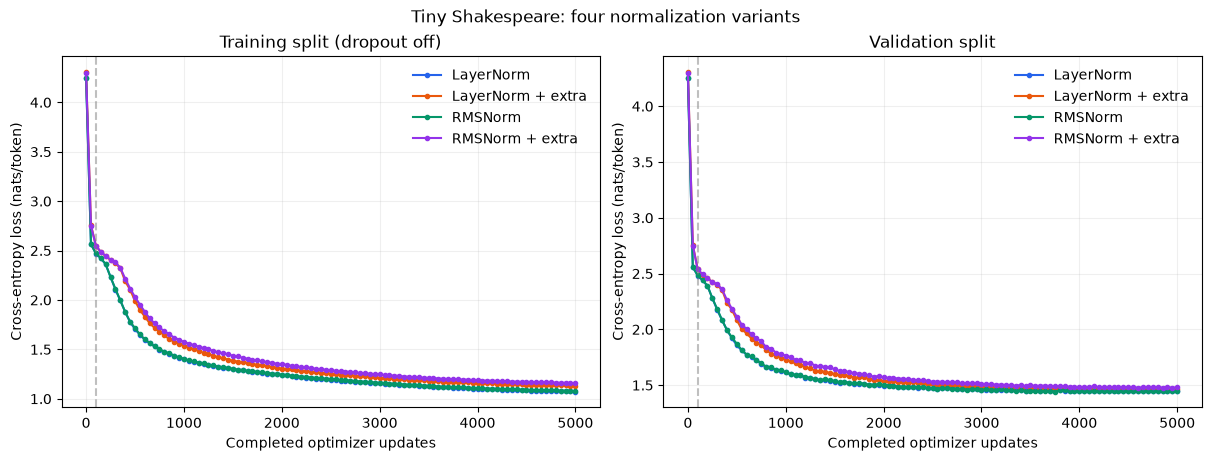

In [8]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# Load saved metrics without creating or training a model.
RESULTS_FILE = None  # Optional: Path('/absolute/path/to/a/run/metrics.json')
if RESULTS_FILE is None:
    if 'RUN_DIR' not in globals():
        raise ValueError('Set RESULTS_FILE to an existing metrics.json, or complete the training cell.')
    RESULTS_FILE = RUN_DIR / 'metrics.json'
RESULTS_FILE = Path(RESULTS_FILE)
saved = json.loads(RESULTS_FILE.read_text())
plot_dir = RESULTS_FILE.parent
runs = {r['id']: r for r in saved['results']}
if saved['status'] != 'complete':
    print('Partial run: plots contain only saved evaluations.')
colors = {'A': '#2563eb', 'B': '#ea580c', 'C': '#059669', 'D': '#9333ea'}

# Compare fixed-window train/validation losses at the same completed update count.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for key, run in runs.items():
    history = run['evaluations']
    for ax, field in zip(axes, ('train_loss', 'val_loss')):
        ax.plot([h['completed_updates'] for h in history], [h[field] for h in history],
                label=run['name'], color=colors[key], marker='o', markersize=3)
for ax, title in zip(axes, ('Training split (dropout off)', 'Validation split')):
    ax.set(title=title, xlabel='Completed optimizer updates', ylabel='Cross-entropy loss (nats/token)')
    ax.axvline(saved['settings']['warmup_iters'], color='gray', linestyle='--', alpha=0.5)
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)
fig.suptitle('Tiny Shakespeare: four normalization variants')
# Save a shareable raster figure and a vector PDF.
fig.savefig(plot_dir / 'loss-by-update.png', dpi=180)
fig.savefig(plot_dir / 'loss-by-update.pdf')
plt.show()
### End normalization-ablation code ###


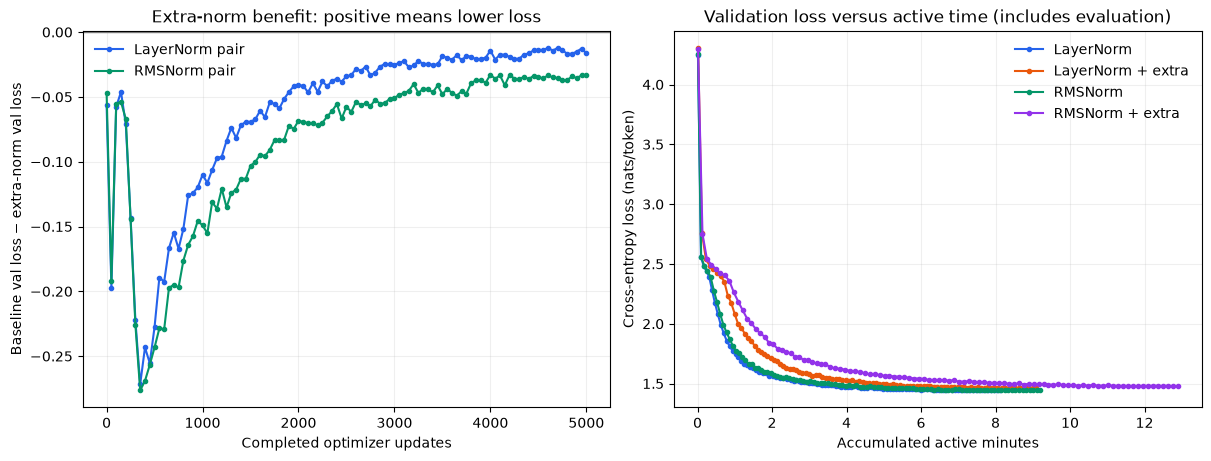

| Variant | Updates | Parameters | Final train loss | Final val loss | Best measured val loss | Elapsed min |
|---|---:|---:|---:|---:|---:|---:|
| LayerNorm | 5000 | 3,230,208 | 1.0735 | 1.4468 | 1.4450 | 8.1 |
| LayerNorm + extra | 5000 | 3,235,328 | 1.1334 | 1.4631 | 1.4598 | 9.1 |
| RMSNorm | 5000 | 3,230,208 | 1.0790 | 1.4468 | 1.4430 | 9.2 |
| RMSNorm + extra | 5000 | 3,235,328 | 1.1598 | 1.4797 | 1.4783 | 12.9 |

Metrics and figures: /Users/linyuntao/Library/Mobile Documents/iCloud~md~obsidian/Documents/obsidian/research_workspace/projects/Adam - Normalization/Code/MiniP/results/shakespeare-normalization/20260914T195408Z-4a3ab271


In [9]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
# Intersect recorded steps so resumed/partial histories are compared fairly.
for baseline_id, extra_id, label in [('A', 'B', 'LayerNorm pair'), ('C', 'D', 'RMSNorm pair')]:
    if baseline_id not in runs or extra_id not in runs:
        continue
    baseline = {h['completed_updates']: h['val_loss'] for h in runs[baseline_id]['evaluations']}
    extra = {h['completed_updates']: h['val_loss'] for h in runs[extra_id]['evaluations']}
    steps = sorted(set(baseline) & set(extra))
    axes[0].plot(steps, [baseline[s] - extra[s] for s in steps],
                 label=label, color=colors[baseline_id], marker='o', markersize=3)
axes[0].axhline(0, color='gray', linewidth=1)
axes[0].set(title='Extra-norm benefit: positive means lower loss',
            xlabel='Completed optimizer updates', ylabel='Baseline val loss − extra-norm val loss')
# Active time includes previous sessions but excludes the pause between them.
for key, run in runs.items():
    h = run['evaluations']
    axes[1].plot([row['elapsed_seconds'] / 60 for row in h], [row['val_loss'] for row in h],
                 label=run['name'], color=colors[key], marker='o', markersize=3)
axes[1].set(title='Validation loss versus active time (includes evaluation)',
            xlabel='Accumulated active minutes', ylabel='Cross-entropy loss (nats/token)')
for ax in axes:
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)
fig.savefig(plot_dir / 'paired-benefit-and-time.png', dpi=180)
fig.savefig(plot_dir / 'paired-benefit-and-time.pdf')
plt.show()

# Display a compact numerical summary alongside the figures.
rows = ['| Variant | Updates | Parameters | Final train loss | Final val loss | Best measured val loss | Elapsed min |',
        '|---|---:|---:|---:|---:|---:|---:|']
for run in runs.values():
    if not run['evaluations']:
        continue
    last = run['evaluations'][-1]
    best = min(h['val_loss'] for h in run['evaluations'])
    elapsed = run.get('elapsed_seconds', last['elapsed_seconds']) / 60
    rows.append(f"| {run['name']} | {last['completed_updates']} | {run['total_params']:,} | "
                f"{last['train_loss']:.4f} | {last['val_loss']:.4f} | {best:.4f} | {elapsed:.1f} |")
display(Markdown('\n'.join(rows)))
print('Metrics and figures:', plot_dir)
### End normalization-ablation code ###


## Interpretation checklist

- Compare A versus B and C versus D at the same completed update count. Report the sign and magnitude of the validation-loss difference, including any negative result.
- Check whether loss is still decreasing near update 1,500 before making a convergence claim.
- Compare training and validation loss to distinguish optimization progress from changes in generalization.
- Treat wall-time results as measurements on this machine under its current load; the variants run sequentially.
- Repeat with additional seeds before claiming a reliable improvement.
- A future depth experiment should specify CompleteP's full initialization, residual scaling, and optimizer settings separately. These results apply to the four-layer ordinary nanoGPT parameterization implemented here.